# Project FORESIGHT – Data Understanding

## Objective
The objective of this notebook is to understand the structure, quality, and relationships of the raw datasets before performing any preprocessing, exploratory data analysis, or modeling.

This notebook focuses on:
- Loading the datasets
- Inspecting their structure
- Identifying data types
- Detecting missing values
- Checking duplicate records
- Understanding relationships between tables
- Documenting key observations

**Dataset:** Retail Contaminated Dataset

In [1]:
# Data manipulation
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt

# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 20)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
from pathlib import Path

# Project root
project_root = Path.cwd().parent

# Raw dataset folder
raw_data_path = project_root / "data" / "raw" / "retail_contaminated_dataset"

print(raw_data_path)

C:\Users\Jairus\project-foresight-demand-inventory-intelligence\data\raw\retail_contaminated_dataset


In [3]:
# Load the sales transactions dataset

sales_df = pd.read_csv(raw_data_path / "sales_transactions.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [4]:
# Display the first five rows

sales_df.head()

,date,receipt_id,store_id,sku_id,customer_id,quantity,unit_price,total_value,channel,discount_pct,promo_id
0,2025-04-02,RCPT00000001,ST16,SKU02498,CUST01410,1,2379.11,2379.11,In-Store,0.0,NaN
1,2025-04-02,RCPT00000001,ST16,SKU04596,CUST01410,3,335.55,1006.65,In-Store,0.0,NaN
2,2022-04-24,RCPT00000002,ST15,SKU00078,CUST00134,1,820.53,820.53,Online,0.0,NaN
3,2022-04-24,RCPT00000002,ST15,SKU00554,CUST00134,2,88.32,176.64,Online,0.0,NaN
4,2024-09-22,RCPT00000003,ST20,SKU03727,CUST08826,1,1660.93,1660.93,Online,0.0,NaN


In [5]:
# Dataset dimensions

print(f"Rows: {sales_df.shape[0]}")
print(f"Columns: {sales_df.shape[1]}")

Rows: 9945511
Columns: 11


In [6]:
# Display all column names

sales_df.columns.tolist()

['date',
 'receipt_id',
 'store_id',
 'sku_id',
 'customer_id',
 'quantity',
 'unit_price',
 'total_value',
 'channel',
 'discount_pct',
 'promo_id']

In [7]:
# Dataset information

sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9945511 entries, 0 to 9945510
Data columns (total 11 columns):
 #   Column        Dtype  
---  ------        -----  
 0   date          object 
 1   receipt_id    object 
 2   store_id      object 
 3   sku_id        object 
 4   customer_id   object 
 5   quantity      int64  
 6   unit_price    float64
 7   total_value   float64
 8   channel       object 
 9   discount_pct  float64
 10  promo_id      object 
dtypes: float64(3), int64(1), object(7)
memory usage: 834.7+ MB


In [8]:
# Missing values

missing_values = sales_df.isnull().sum().sort_values(ascending=False)

missing_values

promo_id        7855345
date                  0
receipt_id            0
store_id              0
sku_id                0
customer_id           0
quantity              0
unit_price            0
total_value           0
channel               0
discount_pct          0
dtype: int64

In [9]:
# Duplicate records

duplicates = sales_df.duplicated().sum()

print(f"Duplicate rows: {duplicates}")

Duplicate rows: 12897


In [10]:
# Summary statistics

sales_df.describe()

,quantity,unit_price,total_value,discount_pct
count,9.945511e+06,9.945511e+06,9.945511e+06,9.945511e+06
mean,1.880336e+00,6.215749e+02,1.094512e+03,6.289965e+00
std,1.089063e+00,6.751952e+02,1.536814e+03,1.383267e+01
min,1.000000e+00,2.441000e+01,1.225000e+01,0.000000e+00
25%,1.000000e+00,1.734300e+02,2.351700e+02,0.000000e+00
50%,2.000000e+00,3.367200e+02,5.432000e+02,0.000000e+00
75%,3.000000e+00,9.256700e+02,1.277610e+03,0.000000e+00
max,5.000000e+00,4.755470e+03,2.377735e+04,4.980000e+01


In [11]:
# Summary of categorical columns

sales_df.describe(include="object")

,date,receipt_id,store_id,sku_id,customer_id,channel,promo_id
count,9945511,9945511,9945511,9945511,9945511,9945511,2090166
unique,1461,5167864,30,5000,10000,3,96
top,2025-12-29,RCPT01092062,ST29,SKU04321,CUST06744,In-Store,PROMO045
freq,9856,5,472578,630147,2303,5496812,185809


In [12]:
# Number of unique values in each column

sales_df.nunique()

date               1461
receipt_id      5167864
store_id             30
sku_id             5000
customer_id       10000
quantity              5
unit_price         4837
total_value      182745
channel               3
discount_pct         84
promo_id             96
dtype: int64

## Initial Observations

### Dataset Overview
- The dataset contains **9,945,511 transaction records** and **11 columns**.
- Each row represents a **single product sold within a transaction (transaction line item)**.
- This is the primary **fact table** for Project FORESIGHT and will be used for demand forecasting, inventory analysis, and business intelligence.

### Data Types
The dataset contains three categories of data:

**Date**
- `date` (currently stored as an object and will be converted to datetime during preprocessing)

**Categorical Variables**
- `receipt_id`
- `store_id`
- `sku_id`
- `customer_id`
- `channel`
- `promo_id`

**Numerical Variables**
- `quantity`
- `unit_price`
- `total_value`
- `discount_pct`

### Data Quality Assessment

#### Missing Values
- Most columns have **no missing values**.
- Only the **promo_id** column contains missing values (**7,855,345 records**).
- This is expected because many sales transactions were not associated with any promotion.

#### Duplicate Records
- The dataset contains **12,897 duplicate rows**.
- These records will be investigated during the preprocessing stage before deciding whether they should be removed.

### Dataset Characteristics
- The dataset covers **1,461 unique dates**.
- It contains transactions from **30 stores**.
- It includes **5,000 unique products (SKUs)**.
- It contains purchase records for **10,000 customers**.
- There are **3 sales channels**.
- There are **96 unique promotions**.

### Table Relationships
The **sales_transactions** table is the central fact table and connects with other datasets through the following keys:

| Related Table | Key |
|---------------|-----|
| customer_master | customer_id |
| sku_master | sku_id |
| store_master | store_id |
| promotions | promo_id |
| inventory_snapshot | sku_id, store_id |

### Conclusion
The dataset is generally of good quality and suitable for further analysis. The main preprocessing tasks will include:
- Converting the `date` column to datetime format.
- Investigating duplicate records.
- Validating missing values in `promo_id`.
- Verifying relationships with the remaining datasets before feature engineering.

In [13]:
customer_df = pd.read_csv(raw_data_path / "customer_master.csv")
sku_df = pd.read_csv(raw_data_path / "sku_master.csv")
store_df = pd.read_csv(raw_data_path / "store_master.csv")
inventory_df = pd.read_csv(raw_data_path / "inventory_snapshot.csv")
promotion_df = pd.read_csv(raw_data_path / "promotions.csv")
inventory_flags_df = pd.read_csv(raw_data_path / "sku_inventory_flags.csv")

In [14]:
datasets = {
    "Sales Transactions": sales_df,
    "Customer Master": customer_df,
    "SKU Master": sku_df,
    "Store Master": store_df,
    "Inventory Snapshot": inventory_df,
    "Promotions": promotion_df,
    "Inventory Flags": inventory_flags_df
}

overview = pd.DataFrame({
    "Dataset": datasets.keys(),
    "Rows": [df.shape[0] for df in datasets.values()],
    "Columns": [df.shape[1] for df in datasets.values()]
})

overview

,Dataset,Rows,Columns
0,Sales Transactions,9945511,11
1,Customer Master,10000,7
2,SKU Master,5000,7
3,Store Master,30,5
4,Inventory Snapshot,26408,6
5,Promotions,100,8
6,Inventory Flags,600,6


## Customer Master Dataset

The `customer_master.csv` dataset contains demographic and loyalty information for customers. It serves as the customer dimension table and can be linked to the sales transactions using the `customer_id` field. This dataset enables customer segmentation, behavioural analysis, and demand forecasting based on customer characteristics.

In [24]:
customer_df.head()

,cust_id,age,gender,city,loyalty_segment,preferred_channel,registration_date
0,CUST00001,52,Female,Sukkur,Silver,Online,2021-01-01
1,CUST00002,41,Female,Karachi,Silver,Mobile App,2021-05-14
2,CUST00003,48,Female,Bahawalpur,Bronze,In-Store,2022-10-23
3,CUST00004,45,Male,Karachi,Silver,In-Store,2015-07-15
4,CUST00005,39,Female,Faisalabad,Bronze,In-Store,2024-01-02


In [16]:
customer_df.shape

(10000, 7)

In [17]:
customer_df.columns

Index(['cust_id', 'age', 'gender', 'city', 'loyalty_segment',
       'preferred_channel', 'registration_date'],
      dtype='object')

In [18]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   cust_id            10000 non-null  object
 1   age                10000 non-null  int64 
 2   gender             10000 non-null  object
 3   city               10000 non-null  object
 4   loyalty_segment    10000 non-null  object
 5   preferred_channel  10000 non-null  object
 6   registration_date  10000 non-null  object
dtypes: int64(1), object(6)
memory usage: 547.0+ KB


In [19]:
customer_df.isnull().sum()

cust_id              0
age                  0
gender               0
city                 0
loyalty_segment      0
preferred_channel    0
registration_date    0
dtype: int64

In [20]:
customer_df.duplicated().sum()

np.int64(0)

In [21]:
customer_df.describe(include="all")

,cust_id,age,gender,city,loyalty_segment,preferred_channel,registration_date
count,10000,10000.000000,10000,10000,10000,10000,10000
unique,10000,NaN,3,15,4,3,3661
top,CUST00001,NaN,Female,Karachi,Bronze,In-Store,2025-02-02
freq,1,NaN,4930,1577,3969,5512,10
mean,NaN,37.702900,NaN,NaN,NaN,NaN,NaN
std,NaN,12.190106,NaN,NaN,NaN,NaN,NaN
min,NaN,18.000000,NaN,NaN,NaN,NaN,NaN
25%,NaN,29.000000,NaN,NaN,NaN,NaN,NaN
50%,NaN,37.000000,NaN,NaN,NaN,NaN,NaN
75%,NaN,46.000000,NaN,NaN,NaN,NaN,NaN


In [22]:
customer_df.nunique()

cust_id              10000
age                     63
gender                   3
city                    15
loyalty_segment          4
preferred_channel        3
registration_date     3661
dtype: int64

### Customer Master Dataset Observations

The Customer Master dataset contains demographic and customer profile information that can be linked to sales transactions using the `cust_id` field. It serves as the customer dimension table in the retail database.

#### Key Findings

- The dataset contains **10,000 customer records** and **7 attributes**.
- Every customer has a unique customer identifier (`cust_id`), indicating that there are no duplicate customer records.
- No missing values were found in any of the columns, suggesting that the dataset is complete.
- There are no duplicate rows, indicating good data quality.
- Customer age ranges from **18 to 80 years**, with an average age of approximately **37.7 years**.
- The dataset contains **3 gender categories**, **15 cities**, **4 loyalty segments**, and **3 preferred shopping channels**.
- Registration dates span **3,661 unique dates**, showing that customers joined over several years.

#### Data Quality Assessment

Overall, the Customer Master dataset is clean and well-structured. No immediate cleaning is required except for converting the `registration_date` column from an object data type to a proper datetime format during preprocessing.

#### Business Importance

This dataset will be useful for:

- Customer segmentation
- Demand forecasting by customer demographics
- Loyalty programme analysis
- Regional sales analysis
- Customer behaviour analysis across different shopping channels

### Planned Preprocessing

The following preprocessing steps will be applied before modelling:

- Convert `registration_date` to datetime format.
- Validate customer IDs against the sales transactions dataset.
- Check for inconsistent category labels in categorical variables.
- Create customer-level features if required during feature engineering.

##  SKU Master Dataset

The `sku_master.csv` dataset contains information about the products (Stock Keeping Units - SKUs) sold by the retail business. It serves as the product dimension table and is linked to sales transactions through the `sku_id` field. This dataset provides product characteristics that are useful for sales analysis, demand forecasting, inventory planning, and category-level reporting.

In [27]:
sku_df.head(10)

,sku_id,sku_name,category,subcategory,unit_price,cost_price,brand
0,SKU00001,NutriPlus Cookware Large,Home & Kitchen,Cookware,813.41,619.77,NutriPlus
1,SKU00002,CrispKing Bread Family Pack,Dairy & Bakery,Bread,70.38,49.57,CrispKing
2,SKU00003,SoftTouch Notebooks 2L,Stationery & Office,Notebooks,151.28,83.67,SoftTouch
3,SKU00004,SunriseFoods Eggs Large,Dairy & Bakery,Eggs,233.64,156.32,SunriseFoods
4,SKU00005,SunriseFoods Pest Control Pack of 6,Home Care,Pest Control,138.50,83.46,SunriseFoods
5,SKU00006,UrbanBite OTC Medicine 100g,Health & Wellness,OTC Medicine,1413.92,830.81,UrbanBite
6,SKU00007,GreenValley Energy Drinks Pack of 12,Beverages,Energy Drinks,129.75,78.97,GreenValley
7,SKU00008,CleanWave Frozen Vegetables 100g,Frozen Foods,Frozen Vegetables,492.11,358.31,CleanWave
8,SKU00009,SmartBuy Frozen Vegetables Medium,Frozen Foods,Frozen Vegetables,251.86,178.03,SmartBuy
9,SKU00010,SparkleClean Footwear 250ml,Apparel & Footwear,Footwear,1602.79,1096.65,SparkleClean


In [28]:
sku_df.shape

(5000, 7)

In [29]:
sku_df.columns

Index(['sku_id', 'sku_name', 'category', 'subcategory', 'unit_price',
       'cost_price', 'brand'],
      dtype='object')

In [30]:
sku_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   sku_id       5000 non-null   object 
 1   sku_name     5000 non-null   object 
 2   category     5000 non-null   object 
 3   subcategory  5000 non-null   object 
 4   unit_price   5000 non-null   float64
 5   cost_price   5000 non-null   float64
 6   brand        5000 non-null   object 
dtypes: float64(2), object(5)
memory usage: 273.6+ KB


In [31]:
sku_df.isnull().sum()

sku_id         0
sku_name       0
category       0
subcategory    0
unit_price     0
cost_price     0
brand          0
dtype: int64

In [32]:
sku_df.duplicated().sum()

np.int64(0)

In [35]:
sku_df.describe(include="all")

,sku_id,sku_name,category,subcategory,unit_price,cost_price,brand
count,5000,5000,5000,5000,5000.000000,5000.000000,5000
unique,5000,4458,12,53,NaN,NaN,30
top,SKU00001,PremiumSelect Cheese Medium,Stationery & Office,Writing Instruments,NaN,NaN,CleanWave
freq,1,3,459,164,NaN,NaN,193
mean,NaN,NaN,NaN,NaN,619.191672,417.040736,NaN
std,NaN,NaN,NaN,NaN,708.009319,480.347009,NaN
min,NaN,NaN,NaN,NaN,24.410000,16.750000,NaN
25%,NaN,NaN,NaN,NaN,160.555000,108.825000,NaN
50%,NaN,NaN,NaN,NaN,318.745000,214.670000,NaN
75%,NaN,NaN,NaN,NaN,788.715000,530.027500,NaN


In [36]:
sku_df.nunique()

sku_id         5000
sku_name       4458
category         12
subcategory      53
unit_price     4837
cost_price     4791
brand            30
dtype: int64

In [37]:
# Calculate product profit margin
sku_df["profit_margin"] = sku_df["unit_price"] - sku_df["cost_price"]

sku_df["profit_margin"].describe()

count    5000.000000
mean      202.150936
std       242.002200
min         6.770000
25%        51.037500
50%       102.575000
75%       250.862500
max      2025.460000
Name: profit_margin, dtype: float64

In [38]:
sku_df.nlargest(10, "profit_margin")[
    ["sku_id", "sku_name", "unit_price", "cost_price", "profit_margin"]
]

,sku_id,sku_name,unit_price,cost_price,profit_margin
586,SKU00587,PurePlus Mobile Accessories Medium,4540.18,2514.72,2025.46
1396,SKU01397,CityFresh Small Appliances Pack of 12,4181.58,2480.40,1701.18
3129,SKU03130,SoftTouch Small Appliances 500g,4194.16,2504.60,1689.56
2060,SKU02061,FamilyChoice Small Appliances Pack of 6,4447.64,2789.75,1657.89
209,SKU00210,MetroBrand Batteries Family Pack,3556.85,1985.27,1571.58
1388,SKU01389,BasicNeeds Mobile Accessories Medium,3609.79,2053.94,1555.85
2844,SKU02845,GoldenHarvest Footwear 2kg,3553.49,2047.79,1505.70
920,SKU00921,SoftTouch Mobile Accessories Pack of 12,3363.82,1875.04,1488.78
1815,SKU01816,BasicNeeds Small Appliances Medium,3324.34,1846.55,1477.79
2832,SKU02833,QuickBite Kids Wear Large,3924.53,2468.33,1456.20


### SKU Master Dataset Observations

The SKU Master dataset contains product information for all Stock Keeping Units (SKUs) sold by the retail business. It acts as the product dimension table and links with the sales transactions through the `sku_id` field.

#### Key Findings

- The dataset contains **5,000 products** described by **7 attributes**.
- Every SKU has a unique identifier (`sku_id`), confirming that each product record is unique.
- No missing values were identified across all columns.
- No duplicate records were found, indicating good data quality.
- The dataset contains:
  - **12 product categories**
  - **53 product subcategories**
  - **30 brands**
- Product names are not completely unique (4,458 unique names), indicating that some products may share the same name but differ in packaging, size, or SKU identifier.
- The average selling price (`unit_price`) is approximately **619.19**, while the average cost price (`cost_price`) is approximately **417.04**.
- Unit prices range from **24.41** to **4755.47**, while cost prices range from **16.75** to **3398.16**, showing a wide variety of products across different price ranges.

#### Data Quality Assessment

The SKU Master dataset is complete and well-structured. No missing values or duplicate records were detected. The only point requiring further investigation is the repeated product names, which should be verified to determine whether they represent legitimate product variants or inconsistencies.

#### Business Importance

This dataset plays a key role in:

- Product performance analysis
- Category and subcategory sales analysis
- Brand performance evaluation
- Profit margin analysis
- Inventory management
- Demand forecasting at the product level

### Planned Preprocessing

The following preprocessing steps will be performed:

- Verify repeated product names to determine whether they represent valid product variants.
- Calculate product profit margin (`unit_price - cost_price`) during feature engineering.
- Validate SKU IDs against the sales transactions dataset.
- Standardize categorical values if inconsistencies are detected.

##  Store Master Dataset

The `store_master.csv` dataset contains information about the retail stores where transactions take place. It serves as the store dimension table and is linked to the sales transactions using the `store_id` field. This dataset provides store attributes that support regional sales analysis, inventory planning, and store performance evaluation.

In [40]:
store_df.head()

,store_id,store_name,city,store_type,opening_date
0,ST01,Quetta Convenience Store #01,Quetta,Convenience Store,2017-07-08
1,ST02,Islamabad Express Store #02,Islamabad,Express Store,2019-05-08
2,ST03,Sialkot Supermarket #03,Sialkot,Supermarket,2019-03-28
3,ST04,Multan Supermarket #04,Multan,Supermarket,2017-10-08
4,ST05,Karachi Supermarket #05,Karachi,Supermarket,2020-11-03


In [41]:
store_df.shape

(30, 5)

In [42]:
store_df.columns

Index(['store_id', 'store_name', 'city', 'store_type', 'opening_date'], dtype='object')

In [43]:
store_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   store_id      30 non-null     object
 1   store_name    30 non-null     object
 2   city          30 non-null     object
 3   store_type    30 non-null     object
 4   opening_date  30 non-null     object
dtypes: object(5)
memory usage: 1.3+ KB


In [44]:
store_df.isnull().sum()

store_id        0
store_name      0
city            0
store_type      0
opening_date    0
dtype: int64

In [45]:
store_df.duplicated().sum()

np.int64(0)

In [46]:
store_df.describe(include="all")

,store_id,store_name,city,store_type,opening_date
count,30,30,30,30,30
unique,30,30,12,4,30
top,ST01,Quetta Convenience Store #01,Karachi,Convenience Store,2017-07-08
freq,1,1,5,11,1


In [47]:
store_df.nunique()

store_id        30
store_name      30
city            12
store_type       4
opening_date    30
dtype: int64

In [48]:
store_df

,store_id,store_name,city,store_type,opening_date
0,ST01,Quetta Convenience Store #01,Quetta,Convenience Store,2017-07-08
1,ST02,Islamabad Express Store #02,Islamabad,Express Store,2019-05-08
2,ST03,Sialkot Supermarket #03,Sialkot,Supermarket,2019-03-28
3,ST04,Multan Supermarket #04,Multan,Supermarket,2017-10-08
4,ST05,Karachi Supermarket #05,Karachi,Supermarket,2020-11-03
...,...,...,...,...,...
25,ST26,Lahore Convenience Store #26,Lahore,Convenience Store,2020-10-29
26,ST27,Rawalpindi Supermarket #27,Rawalpindi,Supermarket,2014-04-12
27,ST28,Karachi Supermarket #28,Karachi,Supermarket,2015-11-15
28,ST29,Karachi Hypermarket #29,Karachi,Hypermarket,2020-07-28


In [49]:
store_df["store_type"].value_counts()

store_type
Convenience Store    11
Supermarket          11
Hypermarket           7
Express Store         1
Name: count, dtype: int64

In [50]:
store_df["city"].value_counts()

city
Karachi       5
Islamabad     4
Multan        4
Quetta        3
Sialkot       3
Sukkur        2
Peshawar      2
Rawalpindi    2
Lahore        2
Hyderabad     1
Faisalabad    1
Gujranwala    1
Name: count, dtype: int64

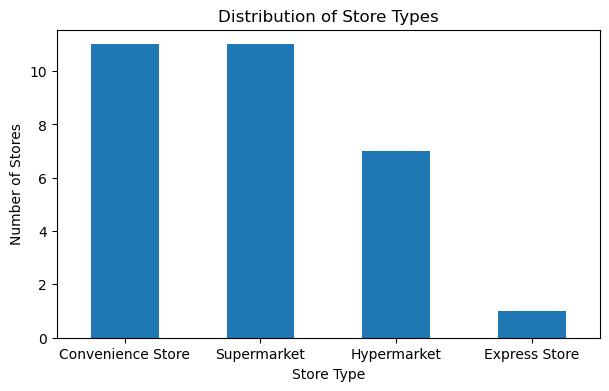

In [51]:
import matplotlib.pyplot as plt

store_df["store_type"].value_counts().plot(
    kind="bar",
    figsize=(7,4),
    title="Distribution of Store Types"
)

plt.xlabel("Store Type")
plt.ylabel("Number of Stores")
plt.xticks(rotation=0)
plt.show()

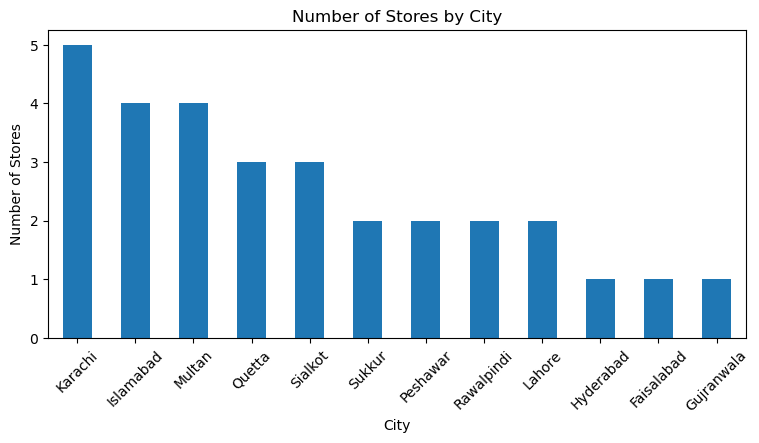

In [52]:
store_df["city"].value_counts().plot(
    kind="bar",
    figsize=(9,4),
    title="Number of Stores by City"
)

plt.xlabel("City")
plt.ylabel("Number of Stores")
plt.xticks(rotation=45)
plt.show()

### Store Master Dataset Observations

The Store Master dataset contains information about the retail stores where sales transactions occur. It functions as the store dimension table and is linked to the sales transactions using the `store_id` field.

#### Key Findings

- The dataset contains **30 retail stores** described by **5 attributes**.
- Every store has a unique identifier (`store_id`) and a unique store name.
- No missing values were found in any of the columns.
- No duplicate records were detected.
- Stores are distributed across **12 cities**.
- The business operates **4 different store types**:
  - Supermarket
  - Hypermarket
  - Convenience Store
  - Express Store
- Each store has a unique opening date, indicating that stores were opened at different periods over time.

#### Data Quality Assessment

The Store Master dataset is complete, consistent, and well-structured. No missing values or duplicate records were identified. The `opening_date` column should be converted to a datetime data type during preprocessing.

#### Business Importance

This dataset will be useful for:

- Store performance analysis
- Regional sales analysis
- Inventory allocation across stores
- Store-level demand forecasting
- Comparing sales across different store formats

### Planned Preprocessing

The following preprocessing steps will be performed:

- Convert `opening_date` to datetime format.
- Validate `store_id` against the sales transactions dataset.
- Create store age features (e.g., years in operation) if required during feature engineering.
- Verify consistency of categorical values in the `store_type` column.

##  Inventory Snapshot Dataset

The `inventory_snapshot.csv` dataset contains inventory information for products across different retail stores at a specific point in time. It links products (`sku_id`) and stores (`store_id`) while recording stock levels and inventory status. This dataset is essential for inventory monitoring, stock optimisation, replenishment planning, and demand forecasting.

In [54]:
inventory_df.head()

,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,last_restock_date
0,ST11,SKU02558,333,72,22,2025-06-23
1,ST21,SKU01031,236,67,14,2025-06-17
2,ST26,SKU02129,496,96,34,2025-07-10
3,ST19,SKU02907,109,34,13,2025-08-17
4,ST05,SKU01023,333,97,22,2025-07-12


In [55]:
inventory_df.shape

(26408, 6)

In [56]:
inventory_df.columns

Index(['store_id', 'sku_id', 'stock_on_hand', 'reorder_point', 'safety_stock',
       'last_restock_date'],
      dtype='object')

In [57]:
inventory_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26408 entries, 0 to 26407
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   store_id           26408 non-null  object
 1   sku_id             26408 non-null  object
 2   stock_on_hand      26408 non-null  int64 
 3   reorder_point      26408 non-null  int64 
 4   safety_stock       26408 non-null  int64 
 5   last_restock_date  26408 non-null  object
dtypes: int64(3), object(3)
memory usage: 1.2+ MB


In [58]:
inventory_df.isnull().sum()

store_id             0
sku_id               0
stock_on_hand        0
reorder_point        0
safety_stock         0
last_restock_date    0
dtype: int64

In [59]:
inventory_df.duplicated().sum()

np.int64(0)

In [60]:
inventory_df.describe(include="all")

,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,last_restock_date
count,26408,26408,26408.000000,26408.000000,26408.000000,26408
unique,30,4495,NaN,NaN,NaN,221
top,ST03,SKU04580,NaN,NaN,NaN,2025-08-31
freq,918,30,NaN,NaN,NaN,211
mean,NaN,NaN,166.195812,59.983301,20.951719,NaN
std,NaN,NaN,142.238780,23.389128,9.873781,NaN
min,NaN,NaN,0.000000,20.000000,4.000000,NaN
25%,NaN,NaN,40.000000,40.000000,13.000000,NaN
50%,NaN,NaN,140.000000,60.000000,20.000000,NaN
75%,NaN,NaN,264.000000,80.000000,28.000000,NaN


In [61]:
inventory_df.nunique()

store_id               30
sku_id               4495
stock_on_hand         595
reorder_point          81
safety_stock           47
last_restock_date     221
dtype: int64

In [62]:
inventory_df.describe()

,stock_on_hand,reorder_point,safety_stock
count,26408.000000,26408.000000,26408.000000
mean,166.195812,59.983301,20.951719
std,142.238780,23.389128,9.873781
min,0.000000,20.000000,4.000000
25%,40.000000,40.000000,13.000000
50%,140.000000,60.000000,20.000000
75%,264.000000,80.000000,28.000000
max,598.000000,100.000000,50.000000


In [63]:
inventory_df.sample(10, random_state=42)

,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,last_restock_date
11503,ST24,SKU00350,84,24,10,2025-06-14
11276,ST14,SKU04475,239,75,35,2025-08-09
14204,ST24,SKU01835,50,73,24,2025-11-04
2805,ST27,SKU00317,302,59,23,2025-08-05
2752,ST13,SKU03089,127,37,9,2025-05-26
17944,ST26,SKU02838,176,59,24,2025-12-28
9109,ST07,SKU01792,121,24,6,2025-08-08
11123,ST09,SKU02211,385,67,15,2025-06-18
12291,ST11,SKU04582,54,96,44,2025-11-15
5511,ST09,SKU01428,119,30,7,2025-06-28


In [64]:
for col in inventory_df.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print(inventory_df[col].value_counts())


store_id
store_id
ST03    918
ST29    914
ST30    913
ST21    907
ST06    898
       ... 
ST19    858
ST27    857
ST02    854
ST20    852
ST13    848
Name: count, Length: 30, dtype: int64

sku_id
sku_id
SKU04580    30
SKU02780    30
SKU03058    30
SKU03773    30
SKU03251    30
            ..
SKU03055     1
SKU01978     1
SKU00556     1
SKU04451     1
SKU04275     1
Name: count, Length: 4495, dtype: int64

last_restock_date
last_restock_date
2025-08-31    211
2025-08-13    199
2025-08-24    197
2025-08-20    184
2025-08-09    184
             ... 
2025-09-08     50
2025-09-20     49
2025-09-25     49
2025-09-07     44
2025-09-13     40
Name: count, Length: 221, dtype: int64


In [65]:
below_reorder = inventory_df[
    inventory_df["stock_on_hand"] < inventory_df["reorder_point"]
]

print("Products below reorder point:", len(below_reorder))

below_reorder.head()

Products below reorder point: 7101


,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,last_restock_date
12,ST01,SKU00500,0,54,24,2025-10-08
16,ST16,SKU01037,0,92,38,2025-09-03
17,ST21,SKU01152,0,76,32,2025-10-02
22,ST08,SKU02381,0,36,15,2025-09-05
36,ST01,SKU03546,0,42,18,2025-08-24


In [66]:
out_of_stock = inventory_df[
    inventory_df["stock_on_hand"] == 0
]

print("Out of stock products:", len(out_of_stock))

out_of_stock.head()

Out of stock products: 4239


,store_id,sku_id,stock_on_hand,reorder_point,safety_stock,last_restock_date
12,ST01,SKU00500,0,54,24,2025-10-08
16,ST16,SKU01037,0,92,38,2025-09-03
17,ST21,SKU01152,0,76,32,2025-10-02
22,ST08,SKU02381,0,36,15,2025-09-05
36,ST01,SKU03546,0,42,18,2025-08-24


In [67]:
inventory_df["inventory_status"] = np.where(
    inventory_df["stock_on_hand"] == 0,
    "Out of Stock",
    np.where(
        inventory_df["stock_on_hand"] < inventory_df["reorder_point"],
        "Below Reorder Level",
        "Sufficient Stock"
    )
)

inventory_df["inventory_status"].value_counts()

inventory_status
Sufficient Stock       19307
Out of Stock            4239
Below Reorder Level     2862
Name: count, dtype: int64

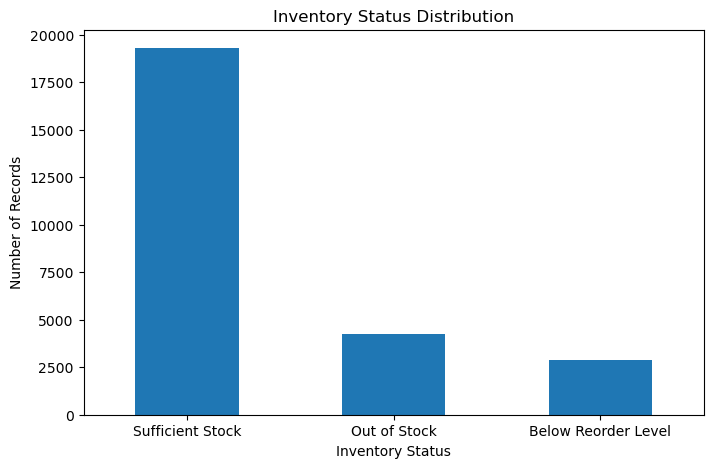

In [68]:
inventory_df["inventory_status"].value_counts().plot(
    kind="bar",
    figsize=(8,5),
    title="Inventory Status Distribution"
)

plt.xlabel("Inventory Status")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.show()

In [69]:
inventory_df.groupby("store_id")["stock_on_hand"] \
.mean() \
.sort_values(ascending=False)

store_id
ST02    175.266979
ST13    173.293632
ST05    171.005669
ST20    170.890845
ST08    170.210526
           ...    
ST15    161.764838
ST14    161.555682
ST19    161.299534
ST10    160.955257
ST30    159.357065
Name: stock_on_hand, Length: 30, dtype: float64

In [70]:
inventory_df.nlargest(
    10,
    "stock_on_hand"
)[["store_id","sku_id","stock_on_hand"]]

,store_id,sku_id,stock_on_hand
9995,ST23,SKU04102,598
23622,ST08,SKU01256,594
7875,ST05,SKU00987,593
10412,ST05,SKU04679,593
1695,ST08,SKU03115,592
2809,ST21,SKU04215,592
4903,ST26,SKU02224,592
218,ST23,SKU00758,591
6631,ST21,SKU04693,591
8546,ST25,SKU00449,591


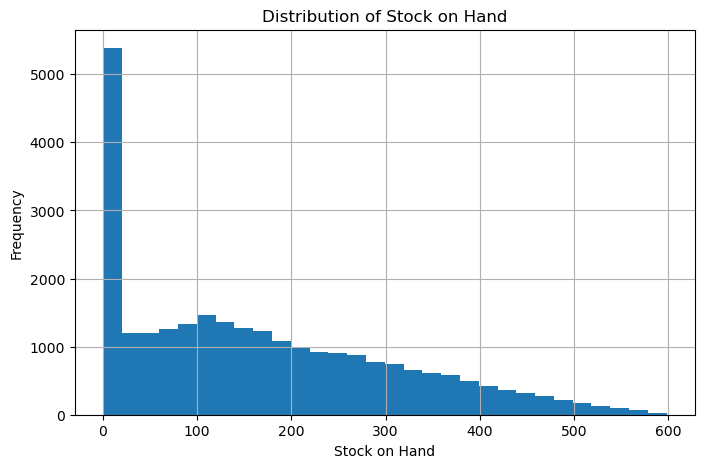

In [71]:
inventory_df["stock_on_hand"].hist(
    bins=30,
    figsize=(8,5)
)

plt.title("Distribution of Stock on Hand")
plt.xlabel("Stock on Hand")
plt.ylabel("Frequency")

plt.show()

### Inventory Snapshot Dataset Observations

The Inventory Snapshot dataset records the inventory status of products across different retail stores. Each record represents the inventory level of a specific product (`sku_id`) at a particular store (`store_id`), together with its stock availability and replenishment information.

#### Key Findings

- The dataset contains **26,408 inventory records** and **6 attributes**.
- Inventory records are distributed across **30 retail stores**.
- The dataset contains **4,495 unique products**, indicating that not every product is stocked in every store.
- No missing values were found in any column.
- No duplicate records were detected.
- The average stock available (`stock_on_hand`) is approximately **166 units**.
- Reorder points average approximately **60 units**, while the average safety stock is approximately **21 units**.
- Stock levels range from **0** to **598 units**, indicating that some products are already out of stock while others are heavily stocked.
- The dataset contains **221 unique restocking dates**, suggesting that inventory is updated frequently.

#### Data Quality Assessment

The Inventory Snapshot dataset is complete, consistent, and free from missing values or duplicate records. The `last_restock_date` column should be converted to a datetime data type before further analysis.

#### Business Importance

This dataset plays a critical role in:

- Inventory monitoring
- Stock replenishment planning
- Stockout detection
- Overstock analysis
- Inventory optimisation
- Demand forecasting
- Supply chain decision-making

### Planned Preprocessing

The following preprocessing steps will be applied:

- Convert `last_restock_date` to datetime format.
- Validate `store_id` and `sku_id` using the Store Master and SKU Master datasets.
- Create inventory-related features such as:
  - Stock status
  - Days since last restock
  - Stock-to-reorder ratio
  - Safety stock ratio
- Identify products below their reorder point.
- Flag products that are out of stock or at risk of stockout.

##  Promotions Dataset

The `promotions.csv` dataset contains information about promotional campaigns offered by the retail business. It links promotional activities to sales transactions through the `promo_id` field. This dataset enables the evaluation of promotion effectiveness, customer purchasing behaviour, and the impact of discounts on product demand.

In [73]:
promotion_df.head()

,promo_id,promo_name,start_date,end_date,discount_pct,promo_type,target_type,target_value
0,PROMO001,Spring Discount Days,2024-07-28,2024-08-02,15.1,BOGO,Brand,NovaFresh
1,PROMO002,Summer Savings Event,2023-03-09,2023-03-21,7.0,Bundle Offer,All,All
2,PROMO003,Payday Discount Days,2025-04-30,2025-05-26,10.2,BOGO,Brand,ZestyCo
3,PROMO004,Super Sale,2025-06-07,2025-06-17,15.9,Clearance,SKU,SKU01108
4,PROMO005,Festive Discount Days,2024-03-23,2024-04-08,46.0,Bundle Offer,All,All


In [74]:
promotion_df.shape

(100, 8)

In [75]:
promotion_df.columns

Index(['promo_id', 'promo_name', 'start_date', 'end_date', 'discount_pct',
       'promo_type', 'target_type', 'target_value'],
      dtype='object')

In [76]:
promotion_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   promo_id      100 non-null    object 
 1   promo_name    100 non-null    object 
 2   start_date    100 non-null    object 
 3   end_date      100 non-null    object 
 4   discount_pct  100 non-null    float64
 5   promo_type    100 non-null    object 
 6   target_type   100 non-null    object 
 7   target_value  100 non-null    object 
dtypes: float64(1), object(7)
memory usage: 6.4+ KB


In [77]:
promotion_df.isnull().sum()

promo_id        0
promo_name      0
start_date      0
end_date        0
discount_pct    0
promo_type      0
target_type     0
target_value    0
dtype: int64

In [78]:
promotion_df.duplicated().sum()

np.int64(0)

In [79]:
promotion_df.describe(include="all")

,promo_id,promo_name,start_date,end_date,discount_pct,promo_type,target_type,target_value
count,100,100,100,100,100.000000,100,100,100
unique,100,72,96,97,NaN,5,4,49
top,PROMO001,Payday Discount Days,2022-01-23,2023-04-18,NaN,Bundle Offer,Category,All
freq,1,5,2,2,NaN,23,38,19
mean,NaN,NaN,NaN,NaN,27.580000,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,14.134348,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,5.000000,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,15.400000,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,25.400000,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,42.575000,NaN,NaN,NaN


In [80]:
promotion_df.nunique()

promo_id        100
promo_name       72
start_date       96
end_date         97
discount_pct     87
promo_type        5
target_type       4
target_value     49
dtype: int64

In [81]:
promotion_df

,promo_id,promo_name,start_date,end_date,discount_pct,promo_type,target_type,target_value
0,PROMO001,Spring Discount Days,2024-07-28,2024-08-02,15.1,BOGO,Brand,NovaFresh
1,PROMO002,Summer Savings Event,2023-03-09,2023-03-21,7.0,Bundle Offer,All,All
2,PROMO003,Payday Discount Days,2025-04-30,2025-05-26,10.2,BOGO,Brand,ZestyCo
3,PROMO004,Super Sale,2025-06-07,2025-06-17,15.9,Clearance,SKU,SKU01108
4,PROMO005,Festive Discount Days,2024-03-23,2024-04-08,46.0,Bundle Offer,All,All
...,...,...,...,...,...,...,...,...
95,PROMO096,Mid-Season Offer,2022-01-30,2022-02-19,7.9,Clearance,Category,Beverages
96,PROMO097,Flash Deal Days,2022-04-18,2022-05-05,43.4,Bundle Offer,SKU,SKU01318
97,PROMO098,Festive Bonanza,2025-01-06,2025-02-03,43.2,Clearance,Category,Dairy & Bakery
98,PROMO099,Flash Sale,2025-10-14,2025-10-22,49.0,Flat Discount,Brand,ValueChoice


In [83]:
promotion_df.describe()

,discount_pct
count,100.000000
mean,27.580000
std,14.134348
min,5.000000
25%,15.400000
50%,25.400000
75%,42.575000
max,49.800000


In [84]:
promotion_df["promo_type"].value_counts()

promo_type
Bundle Offer           23
Percentage Discount    22
Clearance              20
Flat Discount          18
BOGO                   17
Name: count, dtype: int64

In [85]:
promotion_df["target_type"].value_counts()

target_type
Category    38
SKU         22
Brand       21
All         19
Name: count, dtype: int64

In [86]:
promotion_df.groupby("promo_type")["discount_pct"] \
.mean() \
.sort_values(ascending=False)

promo_type
Clearance              33.860000
Percentage Discount    27.672727
Bundle Offer           26.969565
Flat Discount          25.550000
BOGO                   23.047059
Name: discount_pct, dtype: float64

In [87]:
promotion_df.nlargest(
    10,
    "discount_pct"
)[["promo_name","promo_type","discount_pct"]]

,promo_name,promo_type,discount_pct
18,Summer Offer,Bundle Offer,49.8
29,Back to School Offer,Clearance,49.7
87,Back to School Bonanza,Clearance,49.6
7,Winter Deal Days,Flat Discount,49.1
98,Flash Sale,Flat Discount,49.0
76,Weekend Offer,Clearance,48.9
36,Mega Blowout,Percentage Discount,48.6
37,Grand Bonanza,Flat Discount,48.5
31,Back to School Sale,Bundle Offer,48.3
68,Spring Bonanza,Clearance,48.2


In [88]:
promotion_df["start_date"] = pd.to_datetime(promotion_df["start_date"])
promotion_df["end_date"] = pd.to_datetime(promotion_df["end_date"])

promotion_df["promotion_duration"] = (
    promotion_df["end_date"] -
    promotion_df["start_date"]
).dt.days

promotion_df["promotion_duration"].describe()

count    100.000000
mean      17.560000
std        7.546917
min        5.000000
25%       10.000000
50%       18.000000
75%       24.000000
max       30.000000
Name: promotion_duration, dtype: float64

In [89]:
promotion_df.nlargest(
    10,
    "promotion_duration"
)[["promo_name","promotion_duration","discount_pct"]]

,promo_name,promotion_duration,discount_pct
46,Clearance Discount Days,30,42.5
61,Flash Sale,30,43.3
78,Grand Blowout,30,31.1
44,Payday Discount Days,29,22.6
86,Payday Offer,29,19.5
87,Back to School Bonanza,29,49.6
6,Super Offer,28,8.5
22,Anniversary Bonanza,28,14.1
64,Anniversary Sale,28,44.9
94,Clearance Fest,28,8.6


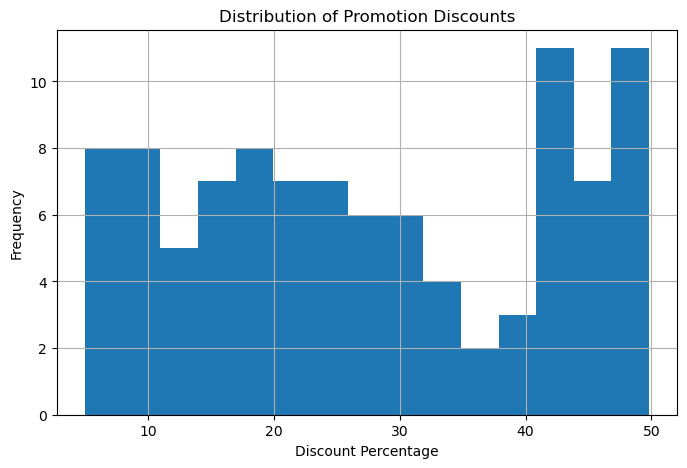

In [90]:
promotion_df["discount_pct"].hist(
    bins=15,
    figsize=(8,5)
)

plt.title("Distribution of Promotion Discounts")
plt.xlabel("Discount Percentage")
plt.ylabel("Frequency")

plt.show()

### Promotions Dataset Observations

The Promotions dataset contains information about promotional campaigns offered by the retail business. It records promotion details such as campaign names, promotion periods, discount percentages, promotion types, and target categories or products.

#### Key Findings

- The dataset contains **100 promotional campaigns** and **8 attributes**.
- Every promotion has a unique identifier (`promo_id`).
- No missing values were found in any column.
- No duplicate records were detected.
- The dataset contains:
  - **5 promotion types**
  - **4 target types**
  - **72 unique promotion names**
- Promotion discounts range from **5%** to **49.8%**.
- The average discount offered is approximately **27.58%**.
- Promotion campaigns cover multiple target levels, including all products, categories, brands, and individual SKUs.
- Promotion periods span multiple years, allowing seasonal and historical promotional analysis.

#### Data Quality Assessment

The Promotions dataset is complete, consistent, and free from missing values or duplicate records. The `start_date` and `end_date` columns should be converted to datetime format during preprocessing.

#### Business Importance

This dataset is useful for:

- Promotion effectiveness analysis
- Measuring the impact of discounts on sales
- Customer purchasing behaviour analysis
- Seasonal campaign analysis
- Demand forecasting during promotional periods
- Marketing performance evaluation

### Planned Preprocessing

The following preprocessing steps will be applied:

- Convert `start_date` and `end_date` to datetime format.
- Calculate promotion duration in days.
- Validate `promo_id` against the Sales Transactions dataset.
- Categorise promotions by duration and discount level.
- Create promotion activity indicators for future modelling.

##  SKU Inventory Flags Dataset

The `sku_inventory_flags.csv` dataset contains inventory status indicators for products. These flags provide additional business information about inventory conditions, such as whether a product is overstocked, understocked, fast-moving, or slow-moving. This dataset supports inventory optimisation, stock monitoring, replenishment planning, and inventory intelligence.

In [92]:
inventory_flags_df.head()

,sku_id,flag,affected_stores,window_start,window_end,notes
0,SKU04321,STOCKOUT_RISK,ST22;ST26;ST23;ST15;ST12;ST28;ST01;ST27;ST08;S...,2025-11-06,2025-12-03,Top-selling SKU (by observed volume); injected...
1,SKU04596,STOCKOUT_RISK,ST12;ST09;ST21;ST23;ST07;ST24;ST01;ST28;ST14;S...,2025-10-25,2025-11-06,Top-selling SKU (by observed volume); injected...
2,SKU03727,STOCKOUT_RISK,ST19;ST14;ST28;ST29;ST02;ST07;ST17;ST08;ST05;ST16,2025-11-08,2025-11-29,Top-selling SKU (by observed volume); injected...
3,SKU04154,STOCKOUT_RISK,ST15;ST03;ST30;ST09;ST24;ST19;ST28;ST02;ST07;S...,2025-11-12,2025-11-26,Top-selling SKU (by observed volume); injected...
4,SKU00953,STOCKOUT_RISK,ST09;ST19;ST27;ST20;ST01;ST03;ST11;ST10;ST22;S...,2025-11-29,2025-12-25,Top-selling SKU (by observed volume); injected...


In [93]:
inventory_flags_df.shape

(600, 6)

In [94]:
inventory_flags_df.columns

Index(['sku_id', 'flag', 'affected_stores', 'window_start', 'window_end',
       'notes'],
      dtype='object')

In [95]:
inventory_flags_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   sku_id           600 non-null    object
 1   flag             600 non-null    object
 2   affected_stores  600 non-null    object
 3   window_start     200 non-null    object
 4   window_end       200 non-null    object
 5   notes            600 non-null    object
dtypes: object(6)
memory usage: 28.3+ KB


In [96]:
inventory_flags_df.isnull().sum()

sku_id               0
flag                 0
affected_stores      0
window_start       400
window_end         400
notes                0
dtype: int64

In [97]:
inventory_flags_df.duplicated().sum()

np.int64(0)

In [98]:
inventory_flags_df.describe(include="all")

,sku_id,flag,affected_stores,window_start,window_end,notes
count,600,600,600,200,200,600
unique,600,2,600,60,62,2
top,SKU04321,SLOW_MOVER,ST22;ST26;ST23;ST15;ST12;ST28;ST01;ST27;ST08;S...,2025-10-29,2025-12-14,Bottom-selling SKU (by observed volume); injec...
freq,1,400,1,7,7,400


In [99]:
inventory_flags_df.nunique()

sku_id             600
flag                 2
affected_stores    600
window_start        60
window_end          62
notes                2
dtype: int64

In [100]:
inventory_flags_df

,sku_id,flag,affected_stores,window_start,window_end,notes
0,SKU04321,STOCKOUT_RISK,ST22;ST26;ST23;ST15;ST12;ST28;ST01;ST27;ST08;S...,2025-11-06,2025-12-03,Top-selling SKU (by observed volume); injected...
1,SKU04596,STOCKOUT_RISK,ST12;ST09;ST21;ST23;ST07;ST24;ST01;ST28;ST14;S...,2025-10-25,2025-11-06,Top-selling SKU (by observed volume); injected...
2,SKU03727,STOCKOUT_RISK,ST19;ST14;ST28;ST29;ST02;ST07;ST17;ST08;ST05;ST16,2025-11-08,2025-11-29,Top-selling SKU (by observed volume); injected...
3,SKU04154,STOCKOUT_RISK,ST15;ST03;ST30;ST09;ST24;ST19;ST28;ST02;ST07;S...,2025-11-12,2025-11-26,Top-selling SKU (by observed volume); injected...
4,SKU00953,STOCKOUT_RISK,ST09;ST19;ST27;ST20;ST01;ST03;ST11;ST10;ST22;S...,2025-11-29,2025-12-25,Top-selling SKU (by observed volume); injected...
...,...,...,...,...,...,...
595,SKU03968,SLOW_MOVER,ST09;ST08;ST17;ST04;ST15;ST22;ST29;ST28;ST25;S...,NaN,NaN,Bottom-selling SKU (by observed volume); injec...
596,SKU02570,SLOW_MOVER,ST22;ST09;ST18;ST30;ST26;ST28;ST01;ST06;ST05;S...,NaN,NaN,Bottom-selling SKU (by observed volume); injec...
597,SKU02662,SLOW_MOVER,ST08;ST10;ST02;ST12;ST19;ST03;ST28;ST07;ST20;S...,NaN,NaN,Bottom-selling SKU (by observed volume); injec...
598,SKU04693,SLOW_MOVER,ST21;ST26;ST09;ST18;ST24;ST20;ST04;ST12;ST03;S...,NaN,NaN,Bottom-selling SKU (by observed volume); injec...


In [101]:
for col in inventory_flags_df.select_dtypes(include="object").columns:
    print(f"\n{col}")
    print(inventory_flags_df[col].value_counts())


sku_id
sku_id
SKU04321    1
SKU00890    1
SKU03619    1
SKU00251    1
SKU02681    1
           ..
SKU00012    1
SKU04953    1
SKU00502    1
SKU03805    1
SKU01863    1
Name: count, Length: 600, dtype: int64

flag
flag
SLOW_MOVER       400
STOCKOUT_RISK    200
Name: count, dtype: int64

affected_stores
affected_stores
ST22;ST26;ST23;ST15;ST12;ST28;ST01;ST27;ST08;ST21;ST24;ST07;ST30;ST20                                                                                    1
ST06;ST04;ST08;ST11;ST15;ST13;ST17;ST26;ST05;ST01;ST27;ST19;ST09;ST16;ST29;ST24;ST10;ST22                                                                1
ST28;ST22;ST29;ST20;ST27;ST24;ST11;ST17;ST16;ST14;ST21;ST09;ST07;ST01;ST30                                                                               1
ST04;ST29;ST12;ST16;ST06;ST03;ST05;ST21;ST30;ST26;ST11;ST18;ST20;ST17;ST25;ST19;ST23;ST01;ST10;ST15;ST28;ST09;ST27;ST07;ST02;ST13                        1
ST30;ST21;ST11;ST20;ST06;ST07;ST18;ST15;ST16;ST12;ST02;ST26;

In [102]:
inventory_flags_df.describe()

,sku_id,flag,affected_stores,window_start,window_end,notes
count,600,600,600,200,200,600
unique,600,2,600,60,62,2
top,SKU04321,SLOW_MOVER,ST22;ST26;ST23;ST15;ST12;ST28;ST01;ST27;ST08;S...,2025-10-29,2025-12-14,Bottom-selling SKU (by observed volume); injec...
freq,1,400,1,7,7,400


### Dataset Observations

- The SKU Inventory Flags dataset contains **600 records** and **6 columns**.
- Each record represents an inventory-related business flag assigned to a specific SKU.
- There are **600 unique SKU IDs**, indicating one inventory flag record per SKU.
- The dataset contains two inventory status categories:
  - **SLOW_MOVER (400 records)**
  - **STOCKOUT_RISK (200 records)**
- The `affected_stores` column lists the stores impacted by each inventory condition.
- Window dates (`window_start` and `window_end`) are only available for Stockout Risk records, while Slow Mover records do not require monitoring windows.

### Data Quality Assessment

- No duplicate records were identified.
- No missing values exist in the SKU identifier, inventory flag, affected stores, or notes columns.
- The `window_start` and `window_end` columns contain **400 missing values**, which correspond to Slow Mover records and therefore appear to be intentional rather than data quality issues.
- All columns are currently stored as object data types.
- The window date columns will require conversion to datetime format during preprocessing.

### Business Importance

The SKU Inventory Flags dataset provides valuable business intelligence by identifying products that require inventory attention.

It supports:

- Stockout risk monitoring
- Inventory replenishment planning
- Slow-moving inventory identification
- Inventory optimisation
- Operational decision-making
- Supply chain monitoring

These inventory flags can later be combined with sales and inventory data to improve demand forecasting and inventory intelligence.

### Planned Preprocessing

The following preprocessing steps will be performed during the Data Preprocessing phase:

- Convert `window_start` and `window_end` to datetime format.
- Validate missing monitoring windows for Slow Mover records.
- Standardise inventory flag categories if necessary.
- Verify consistency between flagged SKUs and inventory records.
- Prepare the dataset for integration with sales and inventory analysis.

#  Relationship Between Datasets

The retail database consists of one central fact table and several supporting dimension tables.

The **Sales Transactions** dataset acts as the primary fact table, while the remaining datasets provide descriptive information about customers, products, stores, inventory, promotional campaigns, and inventory intelligence.

These relationships enable integrated business analysis across sales performance, customer behaviour, inventory management, promotional effectiveness, and demand forecasting.

| Dataset             | Primary Key       | Related Through                                         |
| ------------------- | ----------------- | ------------------------------------------------------- |
| Sales Transactions  | receipt_id        | store_id, sku_id, customer_id, promo_id                 |
| Customer Master     | customer_id       | Sales Transactions                                      |
| SKU Master          | sku_id            | Sales Transactions, Inventory Snapshot, Inventory Flags |
| Store Master        | store_id          | Sales Transactions, Inventory Snapshot                  |
| Inventory Snapshot  | store_id + sku_id | Store Master, SKU Master                                |
| Promotions          | promo_id          | Sales Transactions                                      |
| SKU Inventory Flags | sku_id            | SKU Master                                              |


# Overall Data Quality Assessment

A comprehensive review was conducted across all seven datasets used in Project FORESIGHT.

### Summary

- Seven datasets were successfully analysed.
- Most datasets contained complete records with minimal data quality issues.
- Duplicate records were only identified in the Sales Transactions dataset.
- Missing values were primarily observed in:
  - Promotional identifiers within Sales Transactions.
  - Monitoring windows within SKU Inventory Flags.
- Several date columns remain stored as object data types and will be converted during preprocessing.
- Overall, the datasets are of good quality and suitable for downstream machine learning, exploratory data analysis, demand forecasting, and inventory intelligence.

#  Next Steps

The next phase of Project FORESIGHT focuses on preparing the datasets for analysis and modelling.

The upcoming tasks include:

- Data cleaning and validation
- Handling duplicate records
- Managing missing values
- Converting date columns to datetime format
- Feature engineering
- Data integration
- Exploratory Data Analysis (EDA)
- Demand forecasting model development
- Inventory intelligence modelling
- Dashboard development using Power BI